# Melbourne Rainfall Prediction Using a Decision Tree

## Project Objective

This project builds a binary classification model to predict whether it will rain in Melbourne on the following day using daily weather observations.

**Business question:** Can today's weather conditions provide a useful signal for predicting rain tomorrow?

The workflow covers data inspection, target construction, train-test splitting, baseline modelling, hyperparameter tuning, evaluation, and model interpretation.

> Run the notebook from top to bottom. The data-loading cell searches for daily.csv in the current working directory and in the ADS/ADS2001Group folder.

In [1]:
# Decision Tree: Rain Prediction
# Rain: no rain = 0, rain = 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

## 1. Dataset Overview

The cleaned dataset contains daily Melbourne weather observations. The first inspection checks the dataset dimensions, previews the records, and confirms the available variables before modelling.

The predictors include temperature, humidity, air pressure, wind speed, wind gusts, dew point temperature, apparent temperature, rainfall, and one-hot encoded wind-direction variables.

In [2]:
from pathlib import Path

data_candidates = [
    Path("daily.csv"),
    Path("ADS/ADS2001Group/daily.csv")
]

data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "daily.csv was not found. Place it beside the notebook or update data_candidates."
    )

daily = pd.read_csv(data_path)

print(daily.shape)
daily.head()

(4085, 26)


,WindDir_CALM,WindDir_E,WindDir_ENE,WindDir_ESE,WindDir_N,WindDir_NE,WindDir_NNE,WindDir_NNW,WindDir_NW,WindDir_S,...,WindDir_WSW,Air Temp (degrees C),Humidity (%),MSLP (hPa),Wind Speed (km/h),Wind Gust (km/h),E (hPa),Dew Pt Temp (degrees C),Apparent Temp (degrees C),Rainfall since 9 am (mm)
0,0.0,0.0,0.03876,0.015504,0.007752,0.015504,0.007752,0.000000,0.023256,0.418605,...,0.038760,19.651938,61.635659,1011.784496,14.325581,43.0,13.980619,12.004651,0.0,0.0
1,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.563380,...,0.000000,18.560563,53.718310,1015.983099,22.704225,39.0,11.300188,8.839437,0.0,0.0
2,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,17.300000,51.000000,1016.400000,26.000000,35.0,10.048411,7.100000,0.0,0.0
3,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.008696,0.000000,0.278261,...,0.026087,17.183478,59.608696,1012.045217,15.782609,37.0,11.574564,9.133043,0.0,0.0
4,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007752,0.418605,...,0.093023,18.110853,66.565891,1010.086047,19.837209,37.0,13.699222,11.719380,0.0,0.0


In [3]:
daily.columns

Index(['WindDir_CALM', 'WindDir_E', 'WindDir_ENE', 'WindDir_ESE', 'WindDir_N',
       'WindDir_NE', 'WindDir_NNE', 'WindDir_NNW', 'WindDir_NW', 'WindDir_S',
       'WindDir_SE', 'WindDir_SSE', 'WindDir_SSW', 'WindDir_SW', 'WindDir_W',
       'WindDir_WNW', 'WindDir_WSW', 'Air Temp (degrees C)', 'Humidity (%)',
       'MSLP (hPa)', 'Wind Speed (km/h)', 'Wind Gust  (km/h)', 'E (hPa)',
       'Dew Pt Temp (degrees C)', 'Apparent Temp (degrees C)',
       'Rainfall since 9 am (mm)'],
      dtype='object')

## 2. Define the Prediction Target

The target variable RainTomorrow is created from the next day's rainfall:

- 1 means rainfall is greater than 0 mm on the following day.
- 0 means no rainfall is recorded on the following day.

The final row is removed because it has no following-day observation to provide a label. The model uses today's observations as features, so the prediction is made one day ahead.

In [4]:

daily["RainTomorrow"] = np.where(
    daily["Rainfall since 9 am (mm)"].shift(-1) > 0,
    1,
    0
)

daily = daily.iloc[:-1]

X = daily.drop("RainTomorrow", axis=1)
y = daily["RainTomorrow"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4084, 26)
y shape: (4084,)


In [5]:
X.isnull().sum()

WindDir_CALM                 388
WindDir_E                    388
WindDir_ENE                  388
WindDir_ESE                  388
WindDir_N                    388
WindDir_NE                   388
WindDir_NNE                  388
WindDir_NNW                  388
WindDir_NW                   388
WindDir_S                    388
WindDir_SE                   388
WindDir_SSE                  388
WindDir_SSW                  388
WindDir_SW                   388
WindDir_W                    388
WindDir_WNW                  388
WindDir_WSW                  388
Air Temp (degrees C)         388
Humidity (%)                 388
MSLP (hPa)                   388
Wind Speed (km/h)            388
Wind Gust  (km/h)            388
E (hPa)                      388
Dew Pt Temp (degrees C)      388
Apparent Temp (degrees C)    388
Rainfall since 9 am (mm)       0
dtype: int64

## 3. Train-Test Split

The data is divided into training and testing sets using a chronological 75/25 split. Earlier observations are used for training and later observations are reserved for testing, which better represents the one-day-ahead forecasting task.

In [6]:
split_index = int(len(X) * 0.75)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Training period: rows 0 to", split_index - 1)
print("Testing period: rows", split_index, "to", len(X) - 1)

Training set: (3063, 26)
Testing set: (1021, 26)
Training period: rows 0 to 3062
Testing period: rows 3063 to 4083


## 4. Baseline Decision Tree

An unconstrained decision tree is fitted first as a baseline model. This provides a reference point for judging whether later tuning improves predictive performance.

In [7]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=42)

dtc = dtc.fit(X_train, y_train)

### 4.1 Baseline Evaluation

The baseline is evaluated with accuracy, precision, recall, F1-score, ROC-AUC, a classification report, and a confusion matrix. Because the target is binary, these metrics show both overall performance and how well the model detects rainy days specifically.

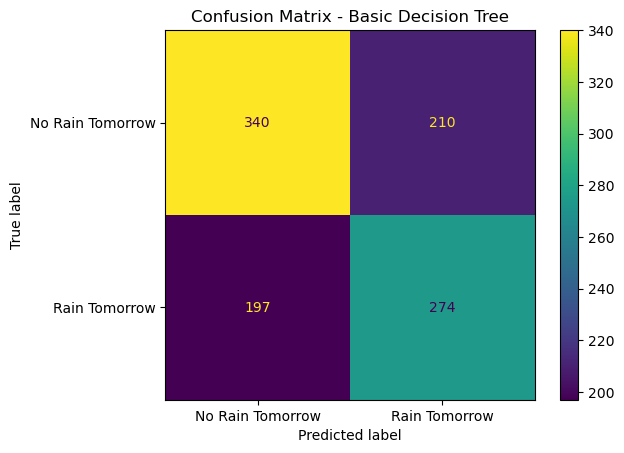

Basic Decision Tree Results
Accuracy: 0.601
Precision: 0.566
Recall: 0.582
F1-score: 0.574
ROC-AUC: 0.596

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.62      0.63       550
           1       0.57      0.58      0.57       471

    accuracy                           0.60      1021
   macro avg       0.60      0.60      0.60      1021
weighted avg       0.60      0.60      0.60      1021



In [8]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)


y_pred = dtc.predict(X_test)
y_pred_proba = dtc.predict_proba(X_test)[:, 1]


cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Rain Tomorrow", "Rain Tomorrow"]
)

disp.plot()
plt.title("Confusion Matrix - Basic Decision Tree")
plt.show()

# Evaluation metrics

print("Basic Decision Tree Results")
print("Accuracy:", np.round(accuracy_score(y_test, y_pred), 3))
print("Precision:", np.round(precision_score(y_test, y_pred), 3))
print("Recall:", np.round(recall_score(y_test, y_pred), 3))
print("F1-score:", np.round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", np.round(roc_auc_score(y_test, y_pred_proba), 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

## 5. Hyperparameter Tuning

Decision trees can become overly complex and fit noise in the training data. Hyperparameters are selected using GridSearchCV with five time-series cross-validation folds on the training set only. F1-score is used as the tuning objective because it balances precision and recall for rainy-day detection; the test set remains untouched until final evaluation.

In [9]:
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10],
    "min_samples_leaf": [1, 5, 10, 20]
}

time_series_cv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=time_series_cv,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_search.cv_results_)
best_params = grid_search.best_params_

depth_results = cv_results[
    cv_results["param_min_samples_leaf"] == best_params["min_samples_leaf"]
][["param_max_depth", "mean_test_score"]].copy()

depth_results["max_depth"] = depth_results["param_max_depth"].astype(int)
depth_results = depth_results.rename(
    columns={"mean_test_score": "cv_f1"}
).sort_values("max_depth")

depth_results[["max_depth", "cv_f1"]]

,max_depth,cv_f1
3,2,0.604239
7,3,0.612136
11,4,0.614397
15,5,0.622471
19,6,0.603066
23,7,0.611196
27,8,0.602904
31,9,0.605236
35,10,0.605407


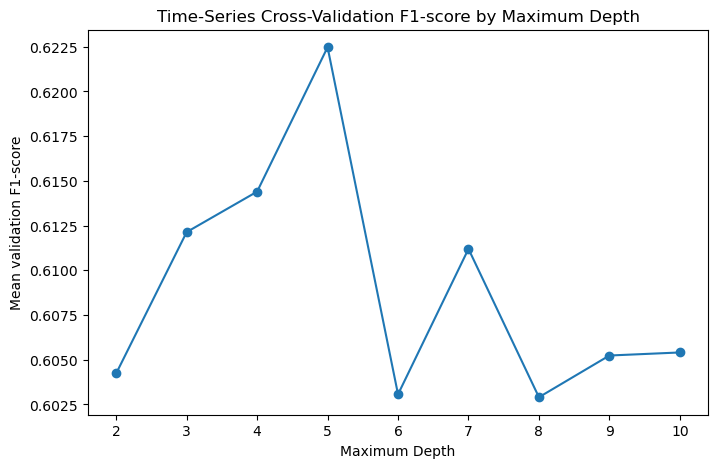

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    depth_results["max_depth"],
    depth_results["cv_f1"],
    marker="o"
)

plt.xlabel("Maximum Depth")
plt.ylabel("Mean validation F1-score")
plt.title("Time-Series Cross-Validation F1-score by Maximum Depth")

plt.show()

## 6. Tuned Model Evaluation

The tuned tree uses the best max_depth and min_samples_leaf combination identified by cross-validation. Requiring a minimum number of observations in each leaf helps reduce very small, unstable decision rules.

The classification threshold is then selected from out-of-fold training predictions to maximise F1-score. This gives the model more opportunity to detect rainy days without using the final test labels to choose the threshold.

Best parameters: {'max_depth': 5, 'min_samples_leaf': 20}
Best mean validation F1-score: 0.622


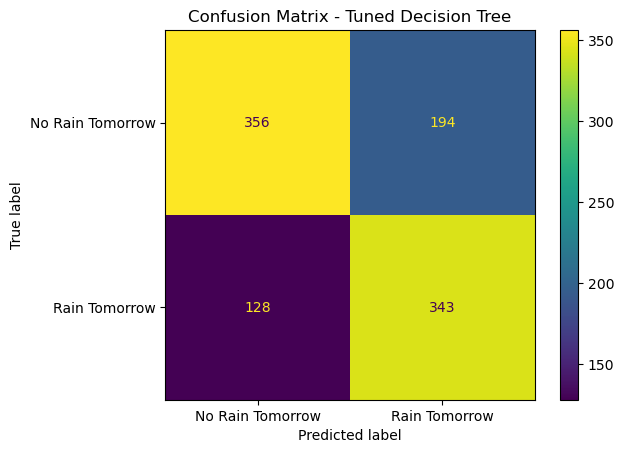

Decision threshold: 0.31
Tuned Decision Tree Results
Accuracy: 0.685
Precision: 0.639
Recall: 0.728
F1-score: 0.681
ROC-AUC: 0.735

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.65      0.69       550
           1       0.64      0.73      0.68       471

    accuracy                           0.68      1021
   macro avg       0.69      0.69      0.68      1021
weighted avg       0.69      0.68      0.68      1021



In [11]:
best_depth = best_params["max_depth"]

print("Best parameters:", best_params)
print("Best mean validation F1-score:", np.round(grid_search.best_score_, 3))

dtc_tuned = grid_search.best_estimator_

threshold_cv = TimeSeriesSplit(n_splits=5)
oof_probabilities = np.full(len(y_train), np.nan)

for train_indices, validation_indices in threshold_cv.split(X_train):
    threshold_model = DecisionTreeClassifier(
        random_state=42,
        **best_params
    )
    threshold_model.fit(
        X_train.iloc[train_indices],
        y_train.iloc[train_indices]
    )
    oof_probabilities[validation_indices] = threshold_model.predict_proba(
        X_train.iloc[validation_indices]
    )[:, 1]

valid_mask = ~np.isnan(oof_probabilities)
thresholds = np.round(np.arange(0.20, 0.61, 0.01), 2)
threshold_f1_scores = [
    f1_score(
        y_train.iloc[valid_mask],
        (oof_probabilities[valid_mask] >= threshold).astype(int)
    )
    for threshold in thresholds
]

decision_threshold = thresholds[int(np.argmax(threshold_f1_scores))]

y_pred_proba_tuned = dtc_tuned.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_pred_proba_tuned >= decision_threshold).astype(int)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["No Rain Tomorrow", "Rain Tomorrow"]
)

disp.plot()
plt.title("Confusion Matrix - Tuned Decision Tree")
plt.show()


print("Decision threshold:", decision_threshold)
print("Tuned Decision Tree Results")
print("Accuracy:", np.round(accuracy_score(y_test, y_pred_tuned), 3))
print("Precision:", np.round(precision_score(y_test, y_pred_tuned), 3))
print("Recall:", np.round(recall_score(y_test, y_pred_tuned), 3))
print("F1-score:", np.round(f1_score(y_test, y_pred_tuned), 3))
print("ROC-AUC:", np.round(roc_auc_score(y_test, y_pred_proba_tuned), 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

### 6.1 Compare with a Majority-Class Baseline

A majority-class classifier always predicts the most common outcome. Comparing against it checks whether the decision tree learns useful patterns beyond a simple class-frequency rule.

In [12]:
baseline_accuracy = y_test.value_counts(normalize=True).max()

print("Baseline accuracy:", np.round(baseline_accuracy, 3))
print("Tuned Decision Tree accuracy:", np.round(accuracy_score(y_test, y_pred_tuned), 3))

Baseline accuracy: 0.539
Tuned Decision Tree accuracy: 0.685


### 6.2 Summary Metrics

The table below consolidates the tuned model's main evaluation metrics in one place for easy comparison and reporting.

In [13]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1-score": f1_score(y_test, y_pred_tuned),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba_tuned)
}

metrics_df = pd.DataFrame(metrics, index=["Decision Tree"]).T
metrics_df["Score"] = metrics_df["Decision Tree"].round(4)
metrics_df = metrics_df[["Score"]]

metrics_df

,Score
Accuracy,0.6846
Precision,0.6387
Recall,0.7282
F1-score,0.6806
ROC-AUC,0.7346


### 6.3 ROC Curve and ROC-AUC

The ROC curve shows the trade-off between the true-positive rate and false-positive rate across classification thresholds. ROC-AUC summarises this ranking ability: a value of 0.5 is equivalent to random ranking, while higher values indicate better discrimination.

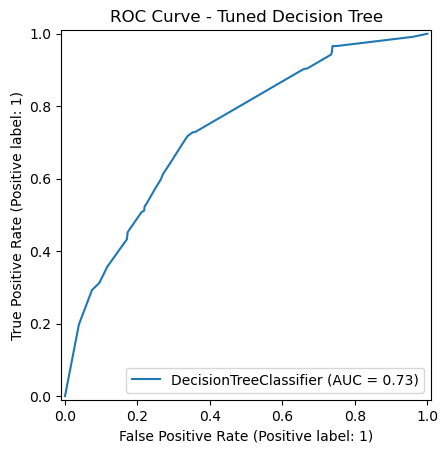

In [14]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(
    dtc_tuned,
    X_test,
    y_test
)

plt.title("ROC Curve - Tuned Decision Tree")
plt.show()

## 7. Feature Importance

Feature importance indicates how much each predictor contributes to the tree's impurity reduction. The plot focuses on the ten most influential variables.

These values describe the model's internal decision process; they should not be interpreted as causal effects.

In [15]:
feature_importance = pd.Series(
    dtc_tuned.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(10)

Rainfall since 9 am (mm)     0.597109
MSLP (hPa)                   0.110654
WindDir_NNE                  0.074437
WindDir_SSE                  0.066405
Air Temp (degrees C)         0.041472
Apparent Temp (degrees C)    0.029346
Dew Pt Temp (degrees C)      0.021453
WindDir_SW                   0.016847
Wind Speed (km/h)            0.012771
WindDir_SE                   0.010118
dtype: float64

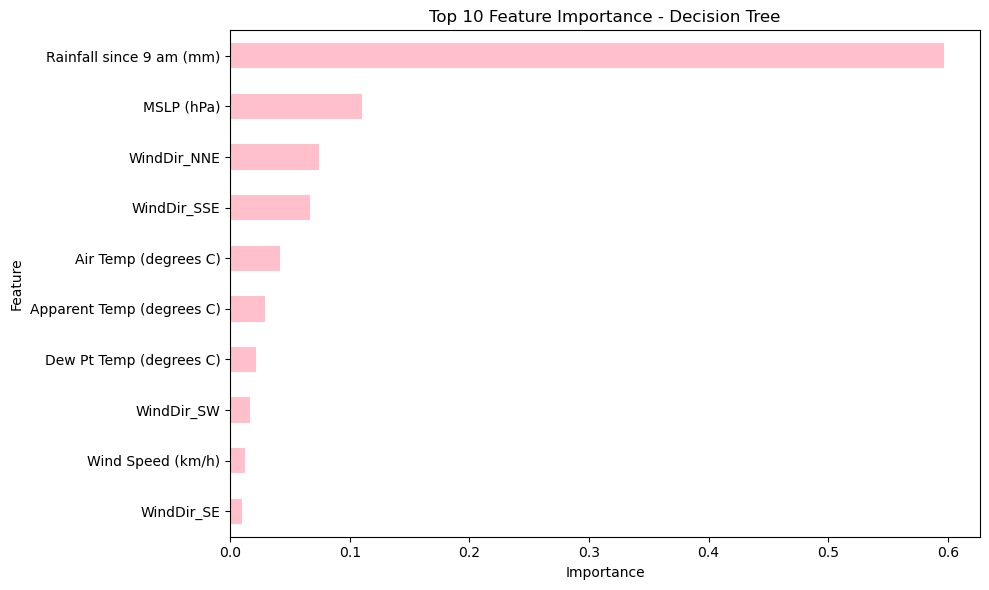

In [16]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(
    kind="barh",
    color="pink"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Decision Tree")

plt.tight_layout()
plt.show()

## 8. Model Interpretation

The final plot displays the learned decision rules. Each split applies a threshold to a weather variable, and the terminal leaves contain the model's predicted class distribution.

The tree is useful for demonstrating interpretability, although a deep tree can become visually crowded. In practice, the most important upper-level splits are usually the easiest to communicate.

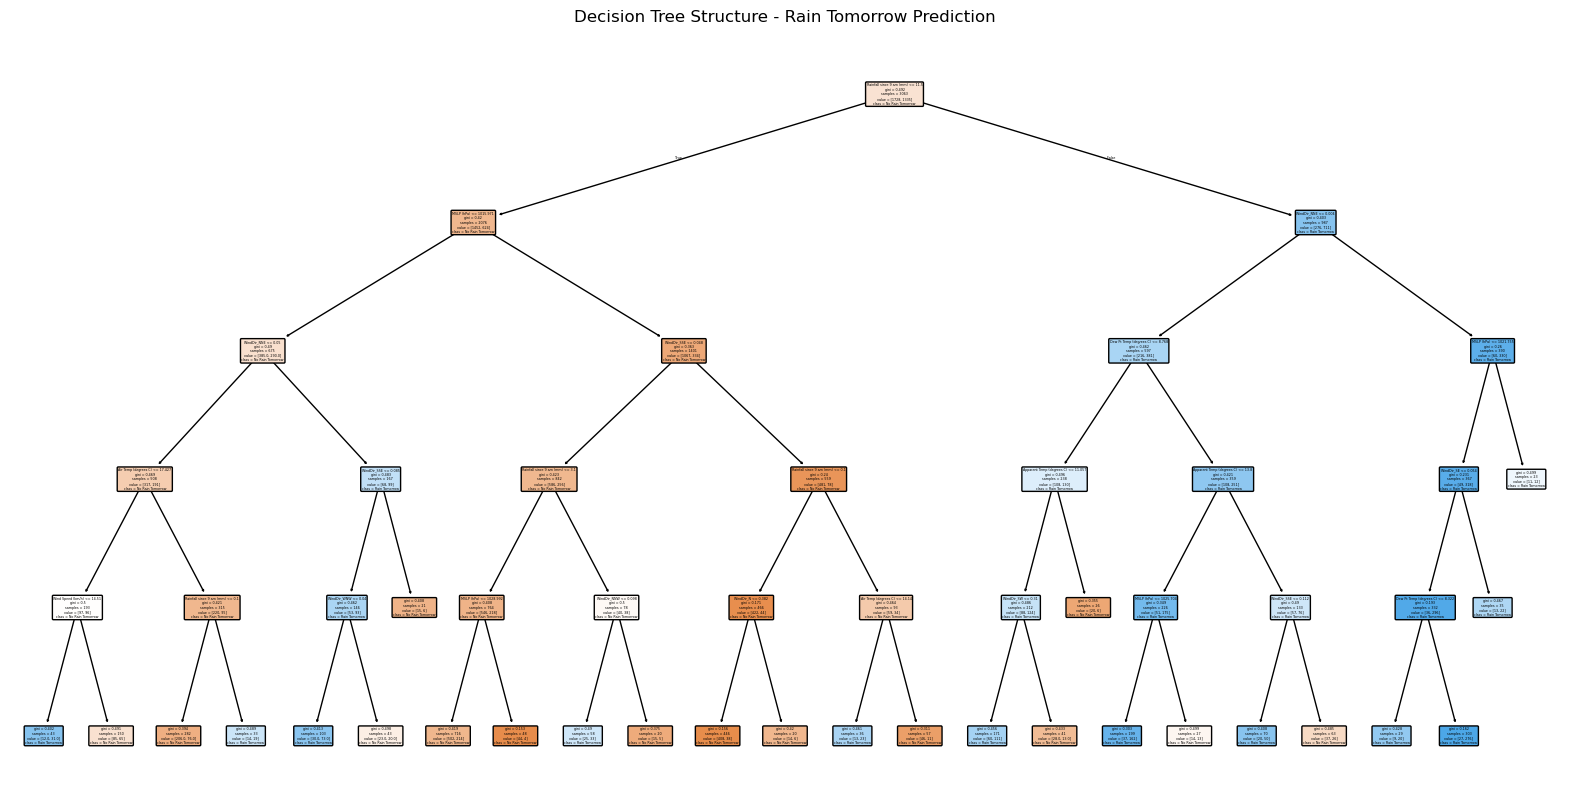

In [17]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    dtc_tuned,
    filled=True,
    rounded=True,
    class_names=["No Rain Tomorrow", "Rain Tomorrow"],
    feature_names=X.columns,
    #max_depth=3
)

plt.title("Decision Tree Structure - Rain Tomorrow Prediction")
plt.show()

## 9. Conclusion

In the current run, the tuned decision tree achieved an accuracy of approximately 0.685 and a ROC-AUC of approximately 0.735, compared with a majority-class baseline accuracy of approximately 0.539. The tuned model therefore learns useful patterns beyond always predicting the most common class.

Using a decision threshold of 0.31, the rainy-day class achieved precision of approximately 0.639, recall of approximately 0.728, and F1-score of approximately 0.681. Compared with the default 0.5 threshold, this intentionally improves rain detection and accepts more false alarms.

The strongest model signal was current-day rainfall, followed by air pressure and several wind and humidity variables. These are model associations rather than causal conclusions.

### Limitations and Next Steps

- The evaluation uses one chronological holdout period. Rolling-origin backtesting would provide a more stable estimate across different seasons and weather regimes.
- The threshold was selected using out-of-fold predictions from the training period, but its stability should be checked across multiple time windows.
- Future work could compare this model with Random Forest or Gradient Boosting, calibrate predicted probabilities, and choose the threshold according to the real cost of missed rain versus false alarms.